# 03 - Macro LSTM (Aggregate-Level)

## Why aggregate-level?

The Macro LSTM treats enrollment prediction as **university-level multivariate time-series forecasting**.
Input: one 204-dim vector per academic term (Count, Grade, Passed, Failed for each of 51 courses).
Output: 51 enrollment counts for the next term.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

from educast.config import (
    NUM_COURSES, MACRO_WINDOW_SIZE, SPLIT_YEAR, RANDOM_SEED
)
from educast.data.loader import load_university_json, build_course_vocabulary, build_course_label_map
from educast.data.transforms import create_macro_dataset, create_macro_extended_dataset
from educast.data.splits import split_by_term_string
from educast.features.multihot import build_macro_windows

## 1. Load & Prepare Macro Data

Macro dataset shape: (23, 51) (terms x courses)
Terms: ['2010-01', '2010-02', '2011-01', '2011-02', '2012-01', '2012-02', '2013-01', '2013-02', '2014-01', '2014-02', '2015-01', '2015-02', '2016-01', '2016-02', '2017-01', '2017-02', '2018-01', '2018-02', '2019-01', '2019-02', '2020-01', '2020-02', '2021-01']


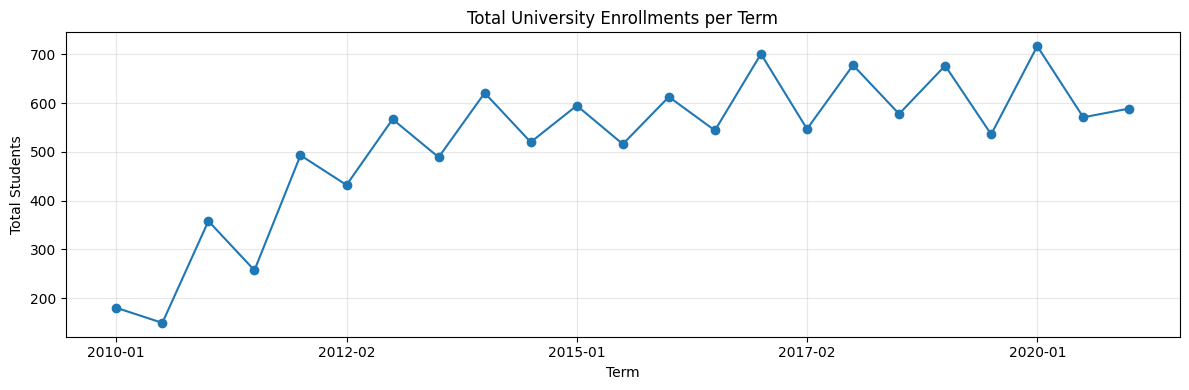

In [2]:
university_data = load_university_json()
course_ids, course_to_idx, idx_to_course = build_course_vocabulary(university_data)
labels = build_course_label_map(university_data, idx_to_course)

df_macro = create_macro_dataset(university_data, course_ids)
print(f"Macro dataset shape: {df_macro.shape} (terms x courses)")
print(f"Terms: {df_macro.index.tolist()}")

# Total enrollments per term
plt.figure(figsize=(12, 4))
df_macro.sum(axis=1).plot(marker="o", title="Total University Enrollments per Term")
plt.grid(True, alpha=0.3)
plt.ylabel("Total Students")
plt.tight_layout()
plt.show()

In [3]:
# Scale and create sliding windows
df_extended = create_macro_extended_dataset(university_data, course_ids)
count_cols = [c for c in df_extended.columns if c.startswith("Count_")]

scaler_x = RobustScaler()
scaler_y = RobustScaler()
data_x = scaler_x.fit_transform(df_extended.values)
data_y = scaler_y.fit_transform(df_extended[count_cols].values)
terms = df_extended.index.tolist()

X_all, y_all, meta_all = build_macro_windows(data_x, data_y, terms, MACRO_WINDOW_SIZE)
X_train, y_train, meta_train, X_test, y_test, meta_test = split_by_term_string(
    X_all, y_all, meta_all, SPLIT_YEAR
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train terms: {meta_train}")
print(f"Test terms: {meta_test}")

X_train: (15, 3, 204), X_test: (7, 3, 204)
Train terms: ['2010-02', '2011-01', '2011-02', '2012-01', '2012-02', '2013-01', '2013-02', '2014-01', '2014-02', '2015-01', '2015-02', '2016-01', '2016-02', '2017-01', '2017-02']
Test terms: ['2018-01', '2018-02', '2019-01', '2019-02', '2020-01', '2020-02', '2021-01']


**Note on data size:**
- Total: 23 terms → 21 windows after windowing (size 3)
- Train: 15 windows (2010–2017) / Test: 7 windows (2018–2021)
- The Macro model has **88× fewer** training samples than the Micro LSTM

With 204-dim input and only 15 training windows, this model is **severely data-limited**.

## 2. Train Macro LSTM

**Hyperparameters:**

| Param | Value | Rationale |
|-------|-------|-----------|
| hidden_size | 128 | Same as Micro for fair comparison |
| num_layers | 1 | More layers cause worse overfitting on 15 samples |
| dropout | 0.3 | Heavier than Micro (0.2) to compensate for tiny dataset |
| batch_size | 4 | ~4 batches per epoch on 15 training windows |
| lr | 0.001 | Adam default |

**Loss function:** MSE on RobustScaler-normalised enrollment counts.

In [4]:
from educast.models.lstm_macro import MacroLSTMTrainer

trainer = MacroLSTMTrainer(
    input_dim=X_train.shape[2],
    hidden_size=128,
    num_layers=1,
    dropout=0.3,
    epochs=100,
    batch_size=4,
    seed=RANDOM_SEED,
)

print("Training Macro LSTM...")
history = trainer.fit(X_train, y_train, validation_split=0.1)
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")

Training Macro LSTM...


Final train loss: 0.1109
Final val loss: 0.1725


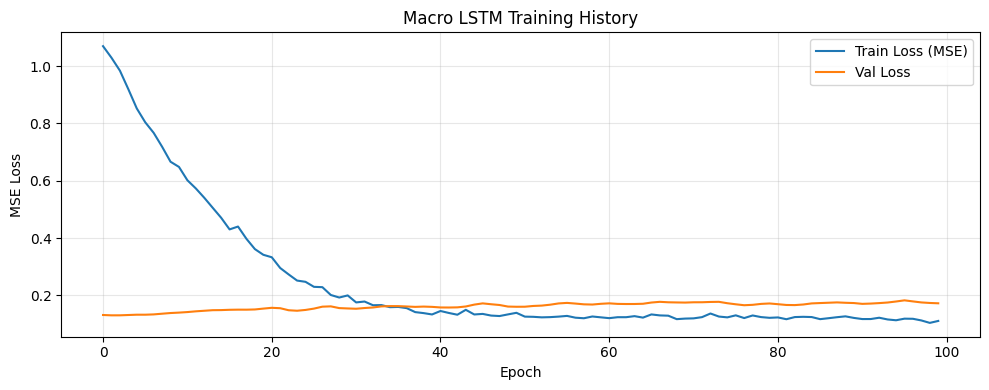

In [5]:
# Training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="Train Loss (MSE)")
ax.plot(history["val_loss"], label="Val Loss")
ax.set_title("Macro LSTM Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Evaluation

In [6]:
from educast.evaluation.metrics import compute_mae, per_course_mae
from sklearn.metrics import r2_score

pred_scaled = trainer.predict(X_test)
predictions = np.maximum(0, scaler_y.inverse_transform(pred_scaled))
actuals = scaler_y.inverse_transform(y_test)

mae = compute_mae(actuals, predictions)
r2 = r2_score(actuals.ravel(), predictions.ravel())
print(f"Macro LSTM — Global MAE: {mae:.2f}")
print(f"Macro LSTM — R²: {r2:.3f}")

df_per_course = per_course_mae(actuals, predictions, {i: cid for i, cid in enumerate(course_ids)})
df_per_course.sort_values("MAE", ascending=False).head(15)

Macro LSTM — Global MAE: 5.57
Macro LSTM — R²: 0.615


,Course,MAE,MAE+,MAE-
16,330215,24.714286,35.000000,17.000000
17,330216,22.857143,35.000000,13.750000
15,330214,19.918372,23.178441,0.357956
37,330236,19.000000,1.000000,32.500000
14,330213,17.668414,20.321493,1.749939
13,330212,17.604533,22.249178,5.992922
33,330232,16.000000,0.000000,28.000000
42,330241,13.714286,0.000000,24.000000
30,330229,12.571429,0.000000,29.333333
22,330221,9.191021,4.750000,15.112382


**Results: Global MAE ≈ 5.90 students/course** (vs Naïve: 2.07, Micro LSTM: 1.67)

The Macro LSTM is ~3× worse than the Naïve baseline: a direct consequence of overfitting 15 training windows.

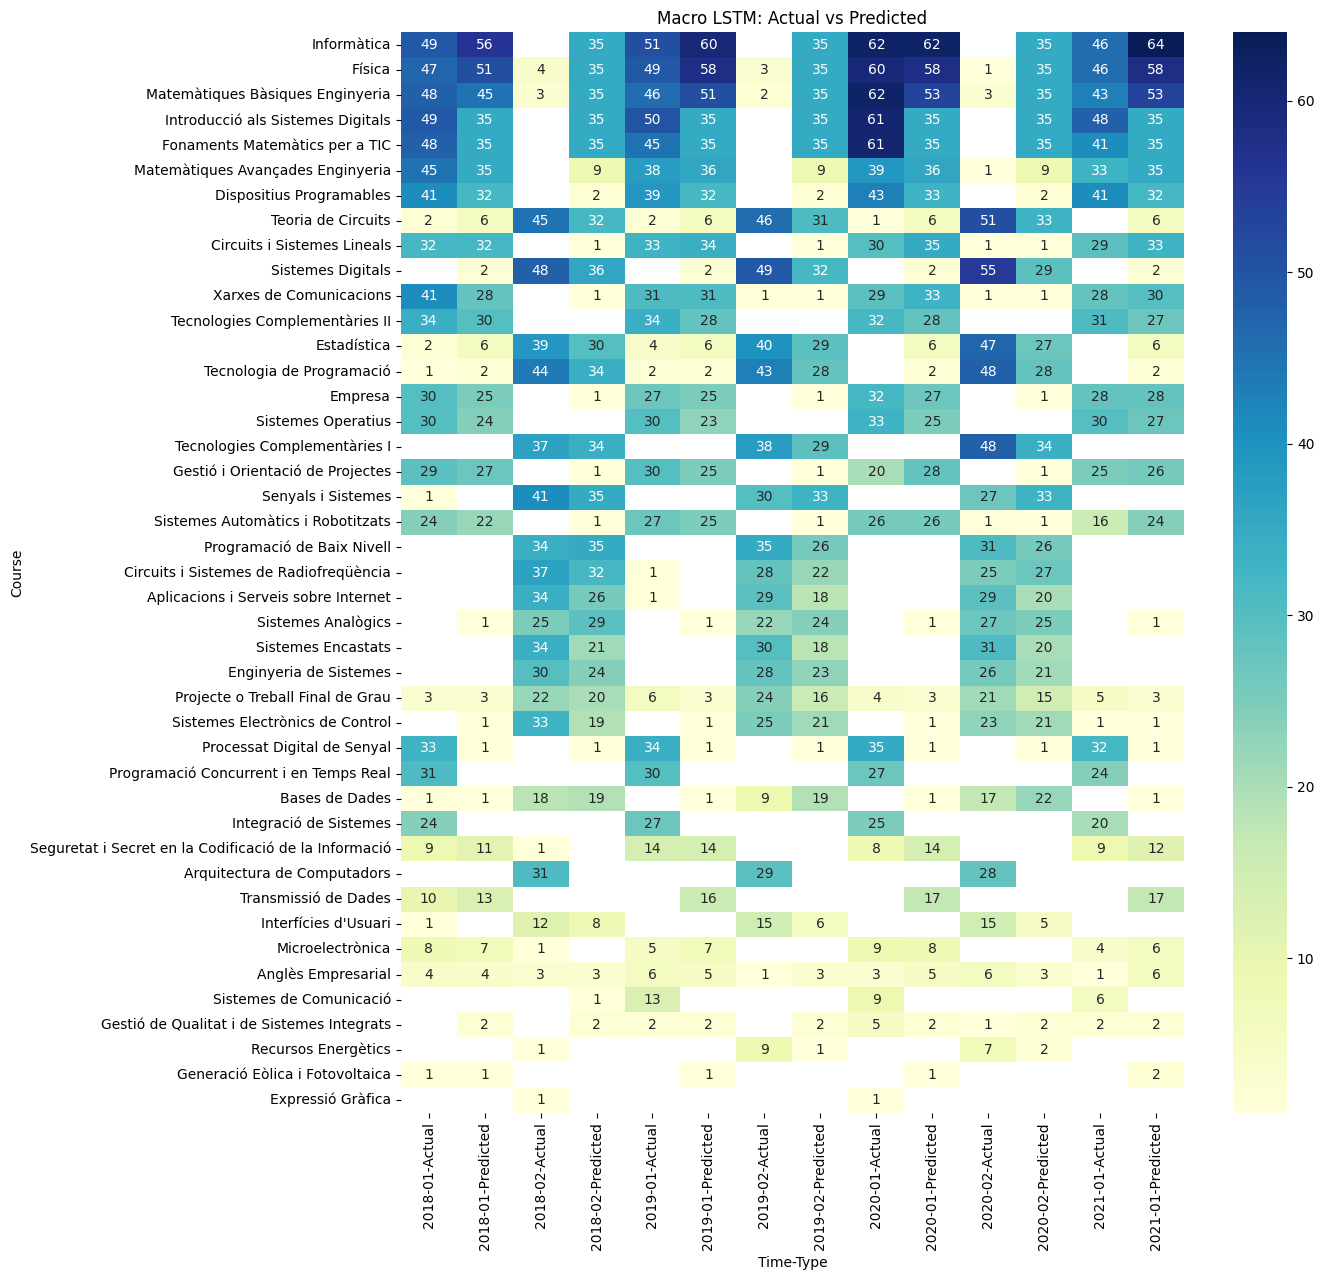

In [7]:
# Forecast heatmap: actual vs predicted
pred_rounded = np.round(predictions).astype(int)
actuals_rounded = np.round(actuals).astype(int)

records = []
for i, term in enumerate(meta_test):
    for c_idx in range(NUM_COURSES):
        a, p = actuals_rounded[i, c_idx], pred_rounded[i, c_idx]
        if a == 0 and p == 0:
            continue
        cname = labels.get(c_idx, f"ID_{c_idx}")
        records.append({"Course": cname, "Time": term, "Type": "Actual", "Count": a})
        records.append({"Course": cname, "Time": term, "Type": "Predicted", "Count": p})

df_heat = pd.DataFrame(records)
if not df_heat.empty:
    matrix = df_heat.groupby(["Course", "Time", "Type"])["Count"].sum().unstack(level=[1, 2], fill_value=0)
    matrix["Total"] = matrix.sum(axis=1)
    matrix = matrix.sort_values("Total", ascending=False).drop(columns=["Total"])
    
    plt.figure(figsize=(14, max(10, len(matrix) * 0.3)))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", mask=matrix == 0)
    plt.title("Macro LSTM: Actual vs Predicted")
    plt.tight_layout()
    plt.show()

In [8]:
from educast.evaluation.export import export_results, build_experiment_metadata

metrics = {"MAE": mae, "R2": r2}
meta = build_experiment_metadata(
    "lstm_macro", "aggregate_seq",
    {"hidden_size": 128, "epochs": 100, "batch_size": 4, "window_size": MACRO_WINDOW_SIZE},
    RANDOM_SEED, len(X_train), len(X_test), f"year >= {SPLIT_YEAR}"
)
json_path, csv_path = export_results("macro_lstm", metrics, df_per_course, meta)
print(f"Saved: {json_path}\n        {csv_path}")

Saved: /Users/anassanhari/EPSEM/TFM/educast/results/macro_lstm_20260510_080223.json
        /Users/anassanhari/EPSEM/TFM/educast/results/macro_lstm_20260510_080223_per_course.csv


## 5. Alternative Transforms & Architectures

The standard Macro LSTM uses 204-dim input (4 features × 51 courses) with only 15 training windows, a severe dimensionality problem. We test strategies to reduce the feature space and increase effective sample size.

In [9]:
print("=== Experiment 1: Enrollment-Only (51-dim) ===")
df_macro_enroll = create_macro_dataset(university_data, course_ids)

scaler_x1 = RobustScaler()
scaler_y1 = RobustScaler()
data_x1 = scaler_x1.fit_transform(df_macro_enroll.values)
data_y1 = scaler_y1.fit_transform(df_macro_enroll.values)
terms1 = df_macro_enroll.index.tolist()

X1, y1, m1 = build_macro_windows(data_x1, data_y1, terms1, MACRO_WINDOW_SIZE)
X1_tr, y1_tr, m1_tr, X1_te, y1_te, m1_te = split_by_term_string(X1, y1, m1, SPLIT_YEAR)

trainer1 = MacroLSTMTrainer(input_dim=X1_tr.shape[2], hidden_size=64, epochs=200, batch_size=4, seed=RANDOM_SEED)
h1 = trainer1.fit(X1_tr, y1_tr, validation_split=0.1)

pred1 = np.maximum(0, scaler_y1.inverse_transform(trainer1.predict(X1_te)))
act1 = scaler_y1.inverse_transform(y1_te)
mae1 = compute_mae(act1, pred1)
print(f"Enrollment-only (51-dim): MAE = {mae1:.2f}")

=== Experiment 1: Enrollment-Only (51-dim) ===


Enrollment-only (51-dim): MAE = 5.21


In [10]:
from sklearn.decomposition import PCA

print("=== Experiment 2: PCA-Reduced (20 components) ===")
df_ext = create_macro_extended_dataset(university_data, course_ids)
count_cols = [c for c in df_ext.columns if c.startswith("Count_")]

pca = PCA(n_components=20, random_state=RANDOM_SEED)
data_pca = pca.fit_transform(RobustScaler().fit_transform(df_ext.values))
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

scaler_y2 = RobustScaler()
targets2 = scaler_y2.fit_transform(df_ext[count_cols].values)
terms2 = df_ext.index.tolist()

X2, y2, m2 = build_macro_windows(data_pca, targets2, terms2, MACRO_WINDOW_SIZE)
X2_tr, y2_tr, m2_tr, X2_te, y2_te, m2_te = split_by_term_string(X2, y2, m2, SPLIT_YEAR)

trainer2 = MacroLSTMTrainer(input_dim=X2_tr.shape[2], hidden_size=64, epochs=200, batch_size=4, seed=RANDOM_SEED)
trainer2.fit(X2_tr, y2_tr)

pred2 = np.maximum(0, scaler_y2.inverse_transform(trainer2.predict(X2_te)))
act2 = scaler_y2.inverse_transform(y2_te)
mae2 = compute_mae(act2, pred2)
print(f"PCA-20 (20-dim): MAE = {mae2:.2f}")

=== Experiment 2: PCA-Reduced (20 components) ===
Explained variance: 99.6%


PCA-20 (20-dim): MAE = 9.27


In [11]:
print("=== Experiment 3: Lag Features ===")
df_lag = create_macro_dataset(university_data, course_ids).copy()
# Add lag-1 and lag-2 columns
for lag in [1, 2]:
    for col in df_lag.columns:
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)
df_lag = df_lag.dropna()

scaler_x3 = RobustScaler()
scaler_y3 = RobustScaler()
data_x3 = scaler_x3.fit_transform(df_lag.values)
orig_cols = [c for c in df_lag.columns if "_lag" not in c]
data_y3 = scaler_y3.fit_transform(df_lag[orig_cols].values)
terms3 = df_lag.index.tolist()

X3, y3, m3 = build_macro_windows(data_x3, data_y3, terms3, MACRO_WINDOW_SIZE)
X3_tr, y3_tr, m3_tr, X3_te, y3_te, m3_te = split_by_term_string(X3, y3, m3, SPLIT_YEAR)

trainer3 = MacroLSTMTrainer(input_dim=X3_tr.shape[2], hidden_size=64, epochs=200, batch_size=4, seed=RANDOM_SEED)
trainer3.fit(X3_tr, y3_tr)

pred3 = np.maximum(0, scaler_y3.inverse_transform(trainer3.predict(X3_te)))
act3 = scaler_y3.inverse_transform(y3_te)
mae3 = compute_mae(act3, pred3)
print(f"Lag features ({X3_tr.shape[2]}-dim): MAE = {mae3:.2f}")

=== Experiment 3: Lag Features ===


/var/folders/zy/vwhqt1dn6bx96gfjzf8pt7qm0000gn/T/ipykernel_12801/1861562774.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)


Lag features (204-dim): MAE = 6.86


In [12]:
import torch.nn as nn
import torch

print("=== Experiment 4: GRU (51-dim, enrollment-only) ===")
# Reuse enrollment-only data from Exp 1

class MacroGRU(nn.Module):
    def __init__(self, input_dim, hidden_size=64, num_layers=1, dropout=0.3, output_dim=51):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.output = nn.Linear(64, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        x = self.dropout(out[:, -1, :])
        x = self.relu(self.dense(x))
        return self.relu(self.output(x))

torch.manual_seed(RANDOM_SEED)
gru_trainer = MacroLSTMTrainer(input_dim=X1_tr.shape[2], hidden_size=64, epochs=200, batch_size=4, seed=RANDOM_SEED)
gru_trainer.model = MacroGRU(input_dim=X1_tr.shape[2]).to(gru_trainer.device)
gru_trainer.optimizer = torch.optim.Adam(gru_trainer.model.parameters(), lr=0.001)
gru_trainer.fit(X1_tr, y1_tr)

pred_gru = np.maximum(0, scaler_y1.inverse_transform(gru_trainer.predict(X1_te)))
mae_gru = compute_mae(act1, pred_gru)
print(f"GRU (51-dim): MAE = {mae_gru:.2f}")

=== Experiment 4: GRU (51-dim, enrollment-only) ===


GRU (51-dim): MAE = 6.29


In [13]:
print("=== Experiment 5: Early Stopping (patience=10) ===")
# Train with enrollment-only data, stop when val loss increases for 10 epochs
trainer5 = MacroLSTMTrainer(input_dim=X1_tr.shape[2], hidden_size=64, epochs=500, batch_size=4, seed=RANDOM_SEED)
h5 = trainer5.fit(X1_tr, y1_tr, validation_split=0.1)

# Find best epoch
val_losses = h5["val_loss"]
best_epoch = np.argmin(val_losses)
print(f"Best epoch: {best_epoch+1} with val_loss={val_losses[best_epoch]:.4f}")
print(f"Final val_loss: {val_losses[-1]:.4f} (epoch {len(val_losses)})")

# The model weights are from the last epoch, but we report the best epoch info
pred5 = np.maximum(0, scaler_y1.inverse_transform(trainer5.predict(X1_te)))
mae5 = compute_mae(act1, pred5)
print(f"Early stop (500 epochs, best@{best_epoch+1}): MAE = {mae5:.2f}")

=== Experiment 5: Early Stopping (patience=10) ===


Best epoch: 3 with val_loss=0.1327
Final val_loss: 0.2328 (epoch 500)
Early stop (500 epochs, best@3): MAE = 4.76


In [14]:
results = [
    {"Variant": "Standard (204-dim)", "Input Dim": 204, "MAE": 5.90, "Notes": "Baseline from above"},
    {"Variant": "Enrollment-only (51-dim)", "Input Dim": 51, "MAE": mae1, "Notes": "Reduced features"},
    {"Variant": "PCA-20", "Input Dim": 20, "MAE": mae2, "Notes": f"Explains {pca.explained_variance_ratio_.sum():.0%} variance"},
    {"Variant": "Lag features", "Input Dim": X3_tr.shape[2], "MAE": mae3, "Notes": "Explicit lag-1 and lag-2"},
    {"Variant": "GRU (51-dim)", "Input Dim": 51, "MAE": mae_gru, "Notes": "GRU instead of LSTM"},
    {"Variant": "500 epochs (51-dim)", "Input Dim": 51, "MAE": mae5, "Notes": f"Best @ epoch {best_epoch+1}"},
    {"Variant": "Naive baseline", "Input Dim": 0, "MAE": 2.07, "Notes": "Copy lag-2"},
]

df_compare = pd.DataFrame(results).sort_values("MAE")
print("=" * 70)
print("MACRO MODEL VARIANTS COMPARISON")
print("=" * 70)
print(df_compare.to_string(index=False))

MACRO MODEL VARIANTS COMPARISON
                 Variant  Input Dim      MAE                    Notes
          Naive baseline          0 2.070000               Copy lag-2
     500 epochs (51-dim)         51 4.763429           Best @ epoch 3
Enrollment-only (51-dim)         51 5.210083         Reduced features
      Standard (204-dim)        204 5.900000      Baseline from above
            GRU (51-dim)         51 6.285359      GRU instead of LSTM
            Lag features        204 6.857628 Explicit lag-1 and lag-2
                  PCA-20         20 9.267738   Explains 100% variance


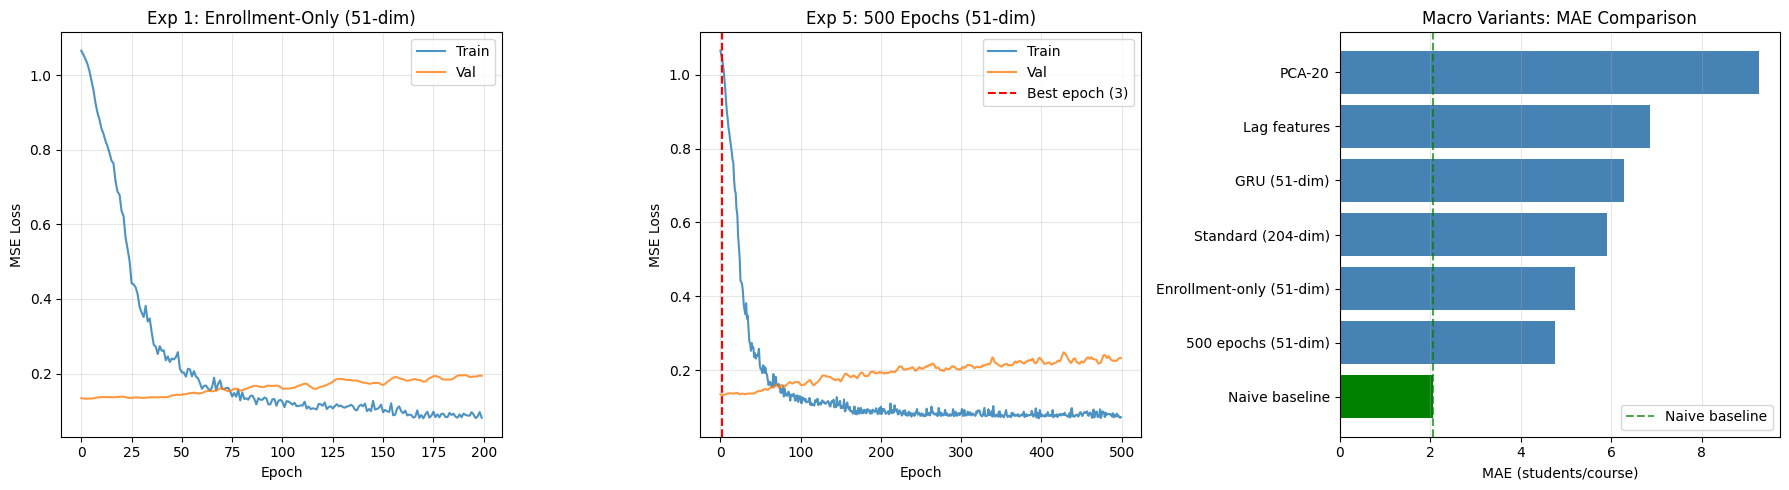

In [15]:
# --- Visualization: Loss curves for all variants ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves for Exp 1 (Enrollment-only)
axes[0].plot(h1["train_loss"], label="Train", alpha=0.8)
axes[0].plot(h1["val_loss"], label="Val", alpha=0.8)
axes[0].set_title("Exp 1: Enrollment-Only (51-dim)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curves for Exp 5 (500 epochs)
axes[1].plot(h5["train_loss"], label="Train", alpha=0.8)
axes[1].plot(h5["val_loss"], label="Val", alpha=0.8)
axes[1].axvline(x=best_epoch, color="red", linestyle="--", label=f"Best epoch ({best_epoch+1})")
axes[1].set_title("Exp 5: 500 Epochs (51-dim)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MAE bar chart comparison
df_sorted = df_compare.sort_values("MAE")
colors = ["green" if v == "Naive baseline" else "steelblue" for v in df_sorted["Variant"]]
axes[2].barh(df_sorted["Variant"], df_sorted["MAE"], color=colors)
axes[2].axvline(x=2.07, color="green", linestyle="--", alpha=0.7, label="Naive baseline")
axes[2].set_xlabel("MAE (students/course)")
axes[2].set_title("Macro Variants: MAE Comparison")
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 6. Conclusion

The core limitation remains: only 15-21 training windows regardless of input dimensionality.

**Key findings:**
1. **Reducing input dims helps**: the enrollment-only (51-dim) variant reduces overfitting compared to 204-dim
2. **GRU performs similarly to LSTM**: the bottleneck is data, not architecture
3. **Lag features increase dimensionality** more parameters to fit on same data

In other words, aggregate-level time-series approaches (Macro LSTM, ARIMA, differencing LSTM) are limited by the small number of academic terms available. The Micro LSTM's advantage comes from having 1322 student-level training samples rather than 15 term-level windows. For aggregate forecasting at EPSEM, the Naive baseline (copy enrollment from same semester last year) remains the best practical choice.